# Longest Divers

**Category:** Data Visualization  
**Dataset:** longest-diving-animals.csv — 108 species, 9 categories, zero missing values  
**Objective:** Build a horizontal bar chart of the longest-diving marine
animals, with a human breath-hold reference point for intuition.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/longest-diving-animals.csv')
df.head()
df['category'].value_counts()

category
other seabirds          40
seals                   24
penguins                14
toothed whales          14
baleen whales            7
sea lions                5
other marine mammals     2
turtles                  1
walruses                 1
Name: count, dtype: int64

## 1. Dataset Exploration

Checking the dataset structure and confirming there are no missing values.

In [3]:
print("Shape: ", df.shape)
print()
print("DataType: ")
print(df.shape)
print()
print("Missing Values: ")
print(df.isnull().sum())

Shape:  (108, 3)

DataType: 
(108, 3)

Missing Values: 
animal      0
category    0
duration    0
dtype: int64


## 2. Feature Engineering: Convert to Hours

Converting dive duration to hours, making the longest dives easier to
interpret while preserving the original values in minutes.

In [ ]:
df['duration_hour'] = df['duration'] / 60

df[['animal', 'category', 'duration', 'duration_hour']].sort_values('duration', ascending=False).head()

,animal,category,duration,duration_hour
97,Cuvier's Beaked Whale,toothed whales,222.0,3.700000
70,Southern Elephant Seal,seals,120.0,2.000000
69,Northern Elephant Seal,seals,119.0,1.983333
67,Weddell Seal,seals,96.0,1.600000
88,Northern Bottlenose Whale,toothed whales,94.0,1.566667


## 3. Visualization: Top 15 Longest Divers

Using a horizontal bar chart for better readability of long species names.
Sorting in ascending order so the longest dives appear at the top.

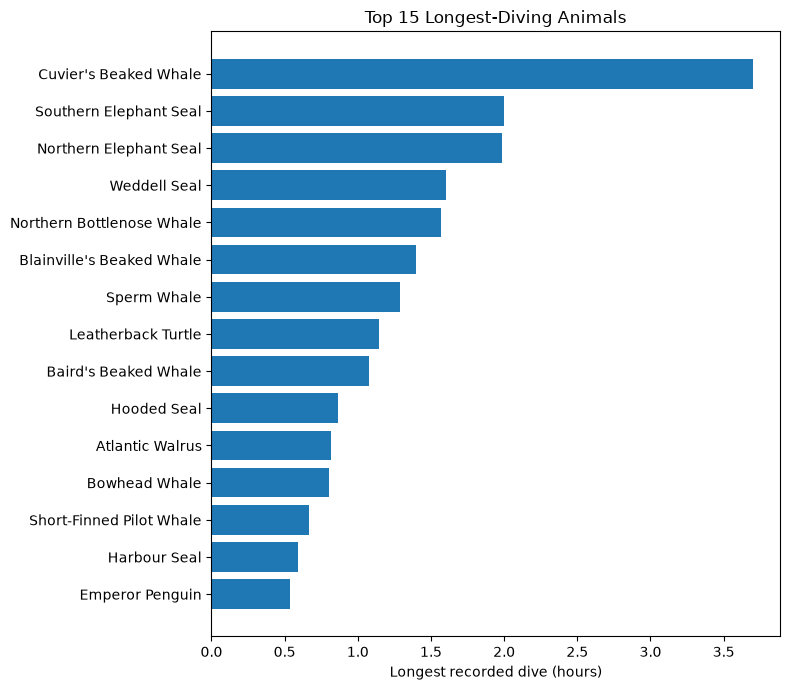

In [9]:
top_15 = df.sort_values('duration', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 7))
plt.barh(
    top_15['animal'],
    top_15['duration_hour'],
    color='C0'
)
ax.set_xlabel('Longest recorded dive (hours)')
ax.set_title('Top 15 Longest-Diving Animals')
plt.tight_layout()
plt.show()

## 4. Adding a Human Reference Line

Adding the human breath-hold record (29 minutes 3 seconds) as a
reference line to provide real-world context for the comparison.

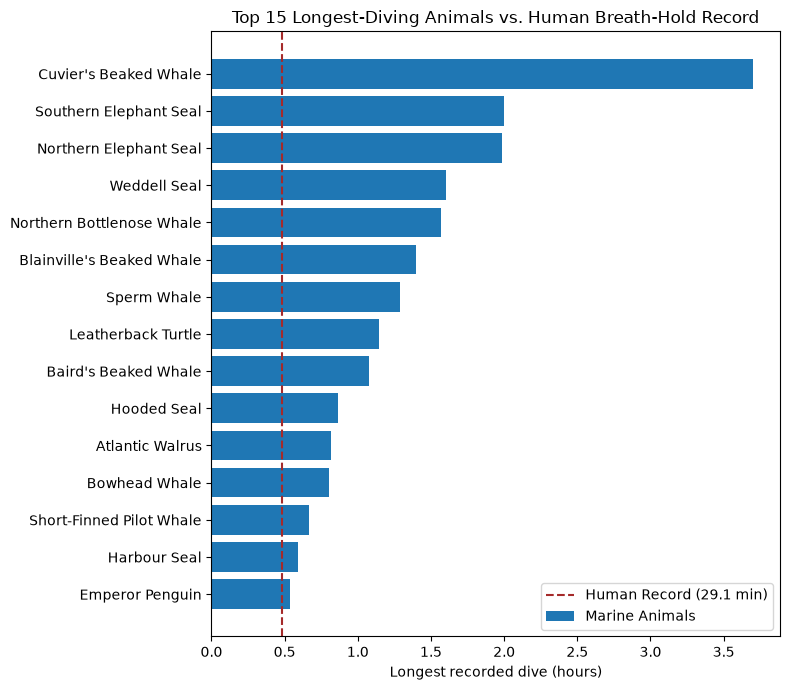

Chart Saved.


In [12]:
human_record_minute = 29 + 3/60 # 29 minutes and 3 seconds
human_record_hour = human_record_minute/60

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    top_15['animal'],
    top_15['duration_hour'],
    color='C0',
    label='Marine Animals'
)
ax.axvline(
    x=human_record_hour,
    color='brown',
    linestyle='--',
    linewidth=1.5,
    label=f'Human Record ({human_record_minute:.1f} min)'
)
ax.set_xlabel('Longest recorded dive (hours)')
ax.set_title('Top 15 Longest-Diving Animals vs. Human Breath-Hold Record')
ax.legend(loc='lower right')

plt.tight_layout()

plt.savefig('../images/plots/top15_divers_vs_human.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 5. Category-Level Comparison

Comparing average dive duration across animal categories while noting
that categories with only one species should be interpreted cautiously.

In [13]:
category_stats = df.groupby('category').agg(
    avg_duration_min=('duration', 'mean'),
    max_duration_min=('duration', 'max'),
    species_count=('animal', 'count')
).sort_values('avg_duration_min', ascending=True)

category_stats

,avg_duration_min,max_duration_min,species_count
category,,,
other seabirds,1.770000,6.2,40
penguins,6.578571,32.2,14
sea lions,11.160000,16.0,5
other marine mammals,17.000000,24.0,2
baleen whales,19.485714,48.0,7
seals,29.079167,120.0,24
toothed whales,48.207143,222.0,14
walruses,49.000000,49.0,1
turtles,68.500000,68.5,1


## 6. Visualization: Average Duration by Category

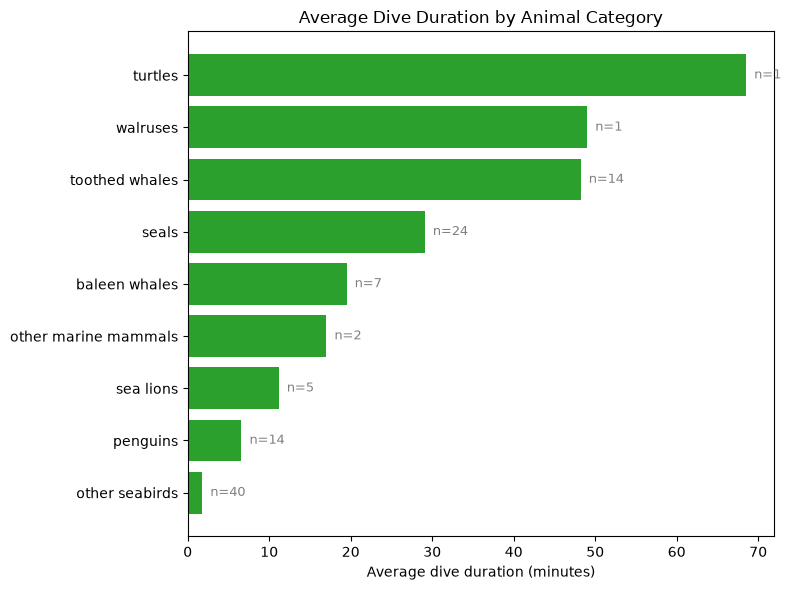

Chart Saved.


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(
    category_stats.index,
    category_stats['avg_duration_min'],
    color='C2'
)

# Annotate each bar with its sample size, since group size ranges from 1 to 40
for bar, n in zip(bars, category_stats['species_count']):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'n={n}',
        va='center',
        fontsize=9,
        color='gray'
    )

ax.set_xlabel('Average dive duration (minutes)')
ax.set_title('Average Dive Duration by Animal Category')
plt.tight_layout()

plt.savefig('../images/plots/average_duration_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 7. My Own Question: Which Category Shows the Greatest Variation in Dive Duration?

Comparing the range of dive durations across categories, excluding
categories represented by only one species.

In [16]:
# Exclude the two 1-species categories since "spread" is meaningless for n=1
meaningful_categories = df[~df['category'].isin(['turtles', 'walruses'])]

spread = meaningful_categories.groupby('category')['duration'].agg(['min', 'max'])
spread['range'] = spread['max'] - spread['min']
spread = spread.sort_values('range', ascending=False)

print(spread)

                       min    max  range
category                                
toothed whales         2.5  222.0  219.5
seals                  3.7  120.0  116.3
baleen whales          7.2   48.0   40.8
penguins               1.5   32.2   30.7
other marine mammals  10.0   24.0   14.0
sea lions              7.5   16.0    8.5
other seabirds         0.1    6.2    6.1


## 8. Key Insights

- **Cuvier's Beaked Whale** recorded the longest dive in the dataset at **222 minutes (3.7 hours)**, remaining underwater for far longer than the human breath-hold record.

- **Toothed whales** appear most frequently among the **15 longest-diving species**, indicating that this group contains many of the world's deepest and longest-duration divers.

- **Turtles** and **walruses** have the highest average dive durations by category, but each category contains only **one species**, so these averages should be interpreted cautiously.

- **Toothed whales** shows the greatest variation in dive duration among categories with multiple species, suggesting substantial differences in diving ability within that group.

- The dataset required **minimal preprocessing**. No missing values were found, and a new **duration in hours** feature was created to improve the readability of long dive durations.